In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

In [29]:
df = pd.read_csv("used_cars.csv")

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [30]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (4009, 12)


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [32]:
df.describe(include='all')

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009.000000,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,NaN,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,NaN,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,NaN,16,3309,52,1037,905,2025,2910,3413,39
mean,NaN,NaN,2015.515590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,6.104816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1974.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
missing = df.isnull().sum()

missing

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


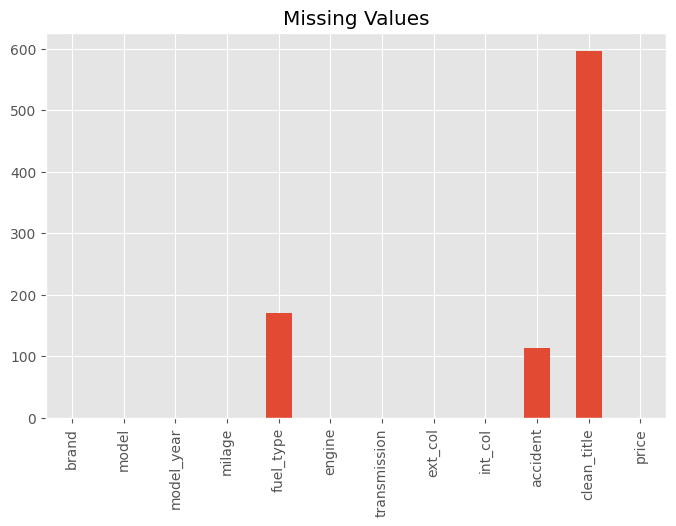

In [34]:
plt.figure(figsize=(8,5))

missing.plot(kind='bar')

plt.title("Missing Values")

plt.show()

In [35]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [36]:
df['price'] = (
    df['price']
    .astype(str)
    .str.replace("$","", regex=False)
    .str.replace(",","", regex=False)
    .astype(float)
)

In [37]:
df['milage'] = (
    df['milage']
    .astype(str)
    .str.replace(",","", regex=False)
    .str.extract('(\d+)')[0]
    .astype(float)
)

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3140/4012280046.py:5: SyntaxWarning: invalid escape sequence '\d'
  .str.extract('(\d+)')[0]


In [38]:
df['fuel_type'].fillna(df['fuel_type'].mode()[0], inplace=True)

df['accident'].fillna("Unknown", inplace=True)

df['clean_title'].fillna("Unknown", inplace=True)

/tmp/ipykernel_3140/4044146026.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['fuel_type'].fillna(df['fuel_type'].mode()[0], inplace=True)
/tmp/ipykernel_3140/4044146026.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [39]:
df.describe()

,model_year,milage,price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


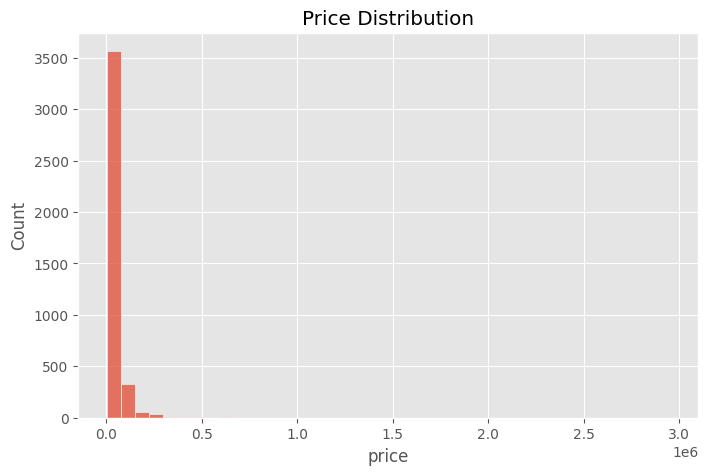

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=40)

plt.title("Price Distribution")

plt.show()

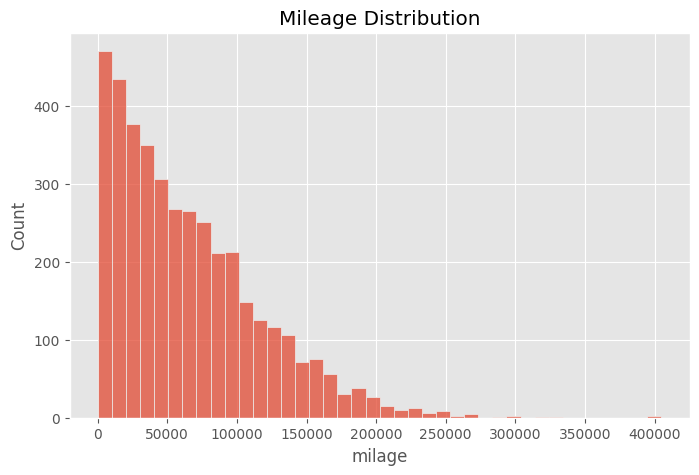

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(df['milage'], bins=40)

plt.title("Mileage Distribution")

plt.show()

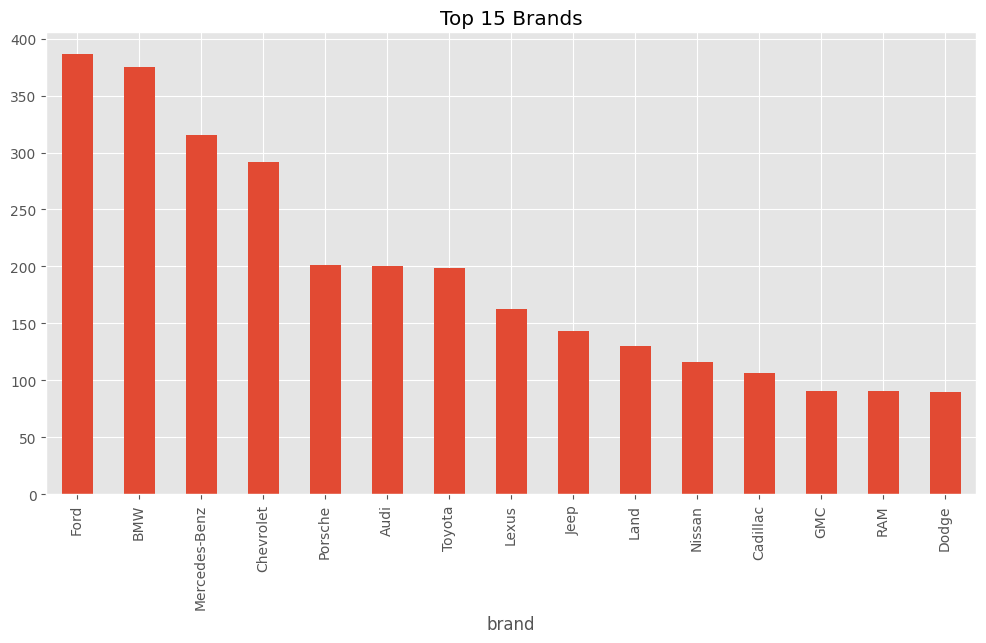

In [42]:
plt.figure(figsize=(12,6))

df['brand'].value_counts().head(15).plot(kind='bar')

plt.title("Top 15 Brands")

plt.show()

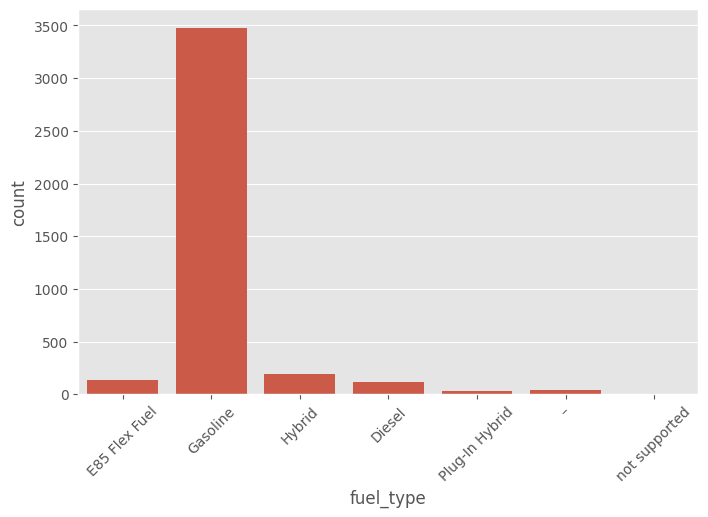

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x='fuel_type')

plt.xticks(rotation=45)

plt.show()

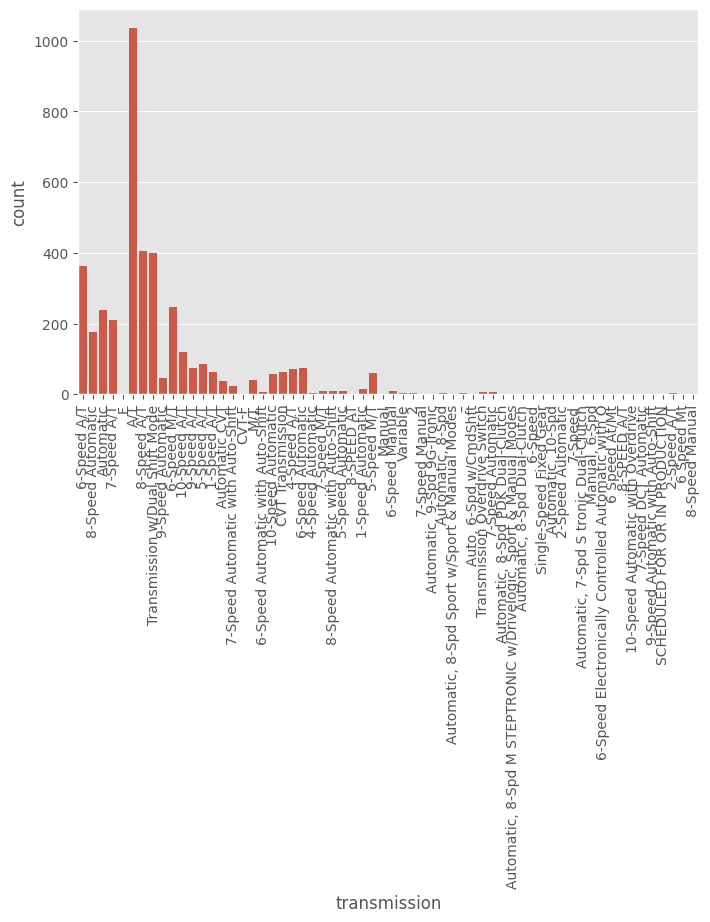

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x='transmission')

plt.xticks(rotation=90)

plt.show()

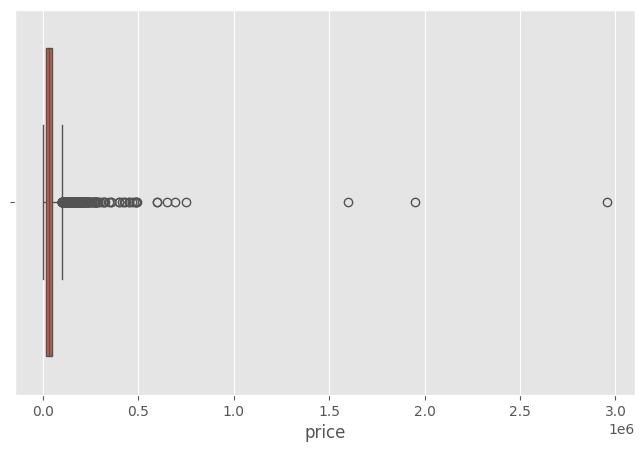

In [45]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['price'])

plt.show()

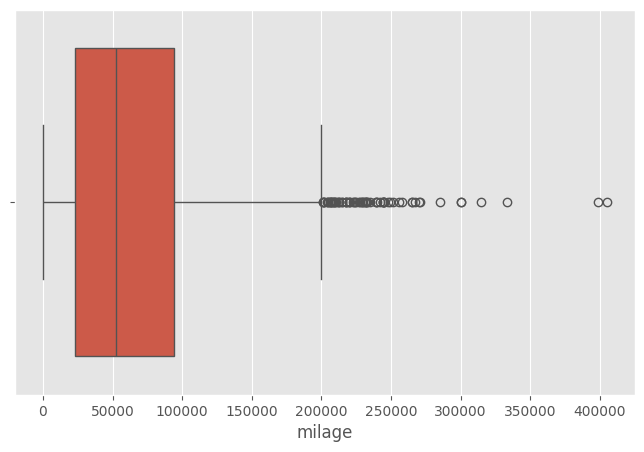

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['milage'])

plt.show()

In [47]:
corr = df[['price','milage','model_year']].corr()

corr

,price,milage,model_year
price,1.000000,-0.305528,0.199496
milage,-0.305528,1.000000,-0.617720
model_year,0.199496,-0.617720,1.000000


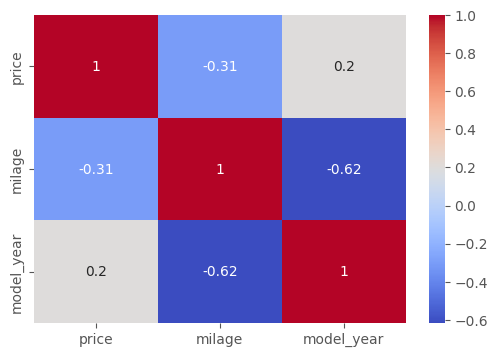

In [48]:
plt.figure(figsize=(6,4))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.show()

In [49]:
CURRENT_YEAR = 2026

df['vehicle_age'] = CURRENT_YEAR - df['model_year']

In [50]:
df['mileage_per_year'] = df['milage'] / (df['vehicle_age'] + 1)

In [51]:
luxury = [
    'BMW',
    'Mercedes-Benz',
    'Audi',
    'Lexus',
    'Porsche',
    'Land',
    'Jaguar'
]

df['is_luxury'] = df['brand'].apply(
    lambda x: 1 if any(i in str(x) for i in luxury) else 0
)

In [52]:
df['has_accident'] = np.where(
    df['accident']=="None reported",
    0,
    1
)

In [53]:
df['clean_title_binary'] = np.where(
    df['clean_title']=="Yes",
    1,
    0
)

In [54]:
df.to_csv("cleaned_used_cars.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [55]:
from google.colab import files

files.download("cleaned_used_cars.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Key Insights

1. The dataset contains over 4,000 used car records from multiple brands.

2. Missing values were found mainly in the `fuel_type`, `accident`, and `clean_title` columns.

3. The `price` and `milage` columns required preprocessing because they were stored as formatted text.

4. Luxury brands generally command higher prices than non-luxury brands.

5. Vehicle age and mileage are expected to have a strong influence on resale price, making them valuable features for predictive modeling.